In [17]:
import matplotlib.pyplot as plt
ms = 50
n_tasks = 512
subtitle = f"n_tasks = {n_tasks}, each task is {ms}ms"
x_axis_workers = [1, 2, 4, 8, 10, 12, 16, 20, 26, 30, 36, 42, 48, 54, 60, 64]
target = [(ms * n_tasks)/i for i in x_axis_workers]
print(target)

[25600.0, 12800.0, 6400.0, 3200.0, 2560.0, 2133.3333333333335, 1600.0, 1280.0, 984.6153846153846, 853.3333333333334, 711.1111111111111, 609.5238095238095, 533.3333333333334, 474.0740740740741, 426.6666666666667, 400.0]


# Processes

In [18]:
processes = [
    [1024, [25699.921, 12857.601, 6441.019, 3235.169, 2628.165, 2226.027, 1694.195, 1426.066, 1096.637, 1098.296, 975.166, 745.479, 795.168, 882.242, 1152.815, 627.56]],
    [4096, [25740.162, 12880.421, 6454.249, 3243.133, 2632.939, 2244.774, 1668.31, 1453.942, 1228.94, 1179.297, 1108.028, 1084.082, 1062.771, 747.567, 1134.008, 995.406]],
    [8192, [25794.107, 12942.189, 6473.017, 3267.272, 2653.387, 2200.289, 1700.913, 1375.988, 1087.482, 1030.041, 964.356, 927.053, 1192.825, 930.75, 849.157, 896.049]],
    [16384, [25891.941, 13011.997, 6504.802, 3273.522, 2659.001, 2279.382, 1730.645, 1435.101, 1219.479, 1236.227, 1081.447, 1146.75, 1153.358, 1070.477, 1234.23, 978.896]],
    [32768, [26088.901, 13137.633, 6566.128, 3307.662, 2715.852, 2243.697, 1714.852, 1421.667, 1372.391, 1044.316, 1076.788, 1185.076, 1134.046, 1155.755, 1435.449, 1399.861]],
    [65536, [26578.671, 13390.146, 6694.501, 3434.896, 2758.194, 2302.637, 1840.544, 1554.104, 1230.921, 1429.095, 1199.387, 1551.769, 1429.488, 1598.647, 1595.893, 2033.734]],
    [524288, [32607.091, 16958.17, 8520.274, 7647.295, 7940.846, 7899.388, 8376.927, 8089.301, 7826.065, 8452.409, 8624.224, 7906.237, 8784.293, 8479.227, 8498.464, 12964.806]],
    [1048576, [39389.046, 20911.859, 16087.733, 15837.989, 15715.213, 15691.626, 16743.939, 16923.648, 16466.566, 16323.826, 16987.228, 16873.304, 16704.29, 17471.039, 17392.059, 24102.23]],
]

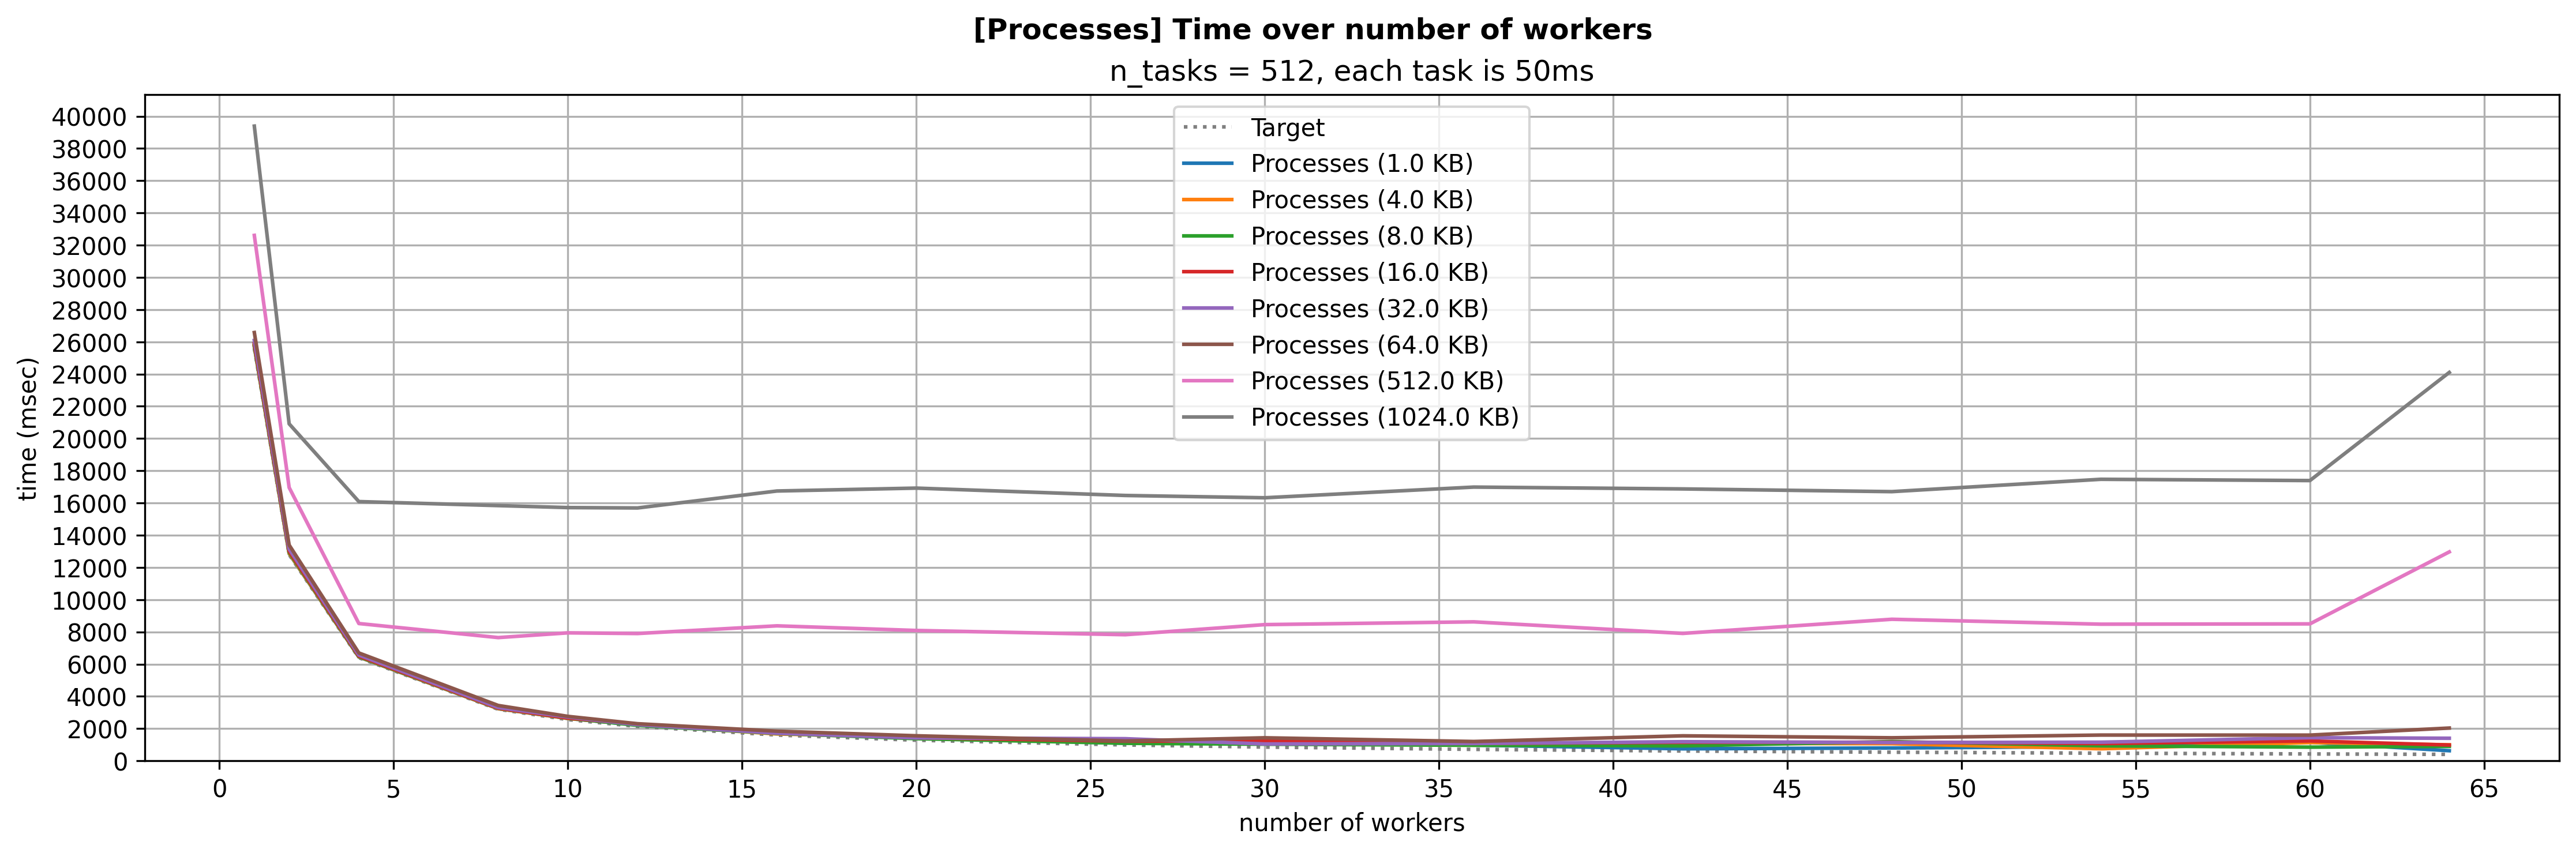

In [19]:
fig, axs = plt.subplots(figsize=(18, 5), dpi=300)
axs.grid()
# Setting the number of ticks
plt.locator_params(axis='x', nbins=len(x_axis_workers)) 
plt.locator_params(axis='y', nbins=24)
plt.plot(x_axis_workers, target, ls="dotted", label="Target", color="grey")
for res in processes:
    plt.plot(x_axis_workers, res[1], label=f"Processes ({res[0] / 1024} KB)")

axs.set_xlabel("number of workers")
axs.set_ylabel("time (msec)")
axs.set_ylim(ymin=0)

plt.suptitle('[Processes] Time over number of workers', y=0.97, fontweight="bold")
plt.title(subtitle)
plt.legend()
#savefig("stream_service_time")
plt.show()

# Subinterpreters

In [20]:
subinterpreters = [
    [1024, [25727.92, 12907.298, 6513.155, 3353.734, 2729.36, 2335.822, 1823.786, 1540.081, 1308.053, 1215.727, 1130.424, 1088.292, 1075.262, 1139.679, 1148.209, 1158.0]],
    [4096, [25768.715, 12927.752, 6535.309, 3353.889, 2733.334, 2306.13, 1833.637, 1577.891, 1336.833, 1219.759, 1151.612, 1094.12, 1110.996, 1099.914, 1125.462, 1160.896]],
    [8192, [25806.033, 12961.531, 6540.578, 3374.623, 2739.531, 2337.694, 1851.678, 1592.95, 1333.041, 1229.074, 1212.993, 1119.029, 1125.75, 1150.677, 1164.54, 1167.316]],
    [16384, [25910.388, 13015.842, 6569.522, 3386.886, 2756.099, 2334.773, 1861.322, 1595.262, 1356.953, 1255.368, 1175.823, 1145.7, 1115.225, 1148.109, 1198.941, 1197.512]],
    [32768, [26097.686, 13106.446, 6621.483, 3419.719, 2780.366, 2361.988, 1869.841, 1621.942, 1319.765, 1254.545, 1235.056, 1170.622, 1160.126, 1214.386, 1201.17, 1245.139]],
    [65536, [26477.558, 13326.825, 6749.681, 3471.185, 2830.488, 2420.055, 1929.0, 1671.784, 1415.432, 1322.231, 1230.076, 1381.259, 1256.786, 1401.778, 1545.387, 1594.439]],
    [524288, [31649.882, 16093.954, 8396.406, 8089.079, 7944.209, 8039.08, 8091.909, 8061.244, 8165.698, 8257.655, 8188.382, 8860.677, 8166.868, 8143.988, 8165.96, 11857.307]],
    [1048576, [37733.956, 19327.821, 15865.447, 15438.715, 15357.766, 15437.643, 15931.93, 15787.879, 15955.424, 15926.648, 15737.713, 15678.617, 15810.114, 15964.421, 16924.99, 23046.367]],
]

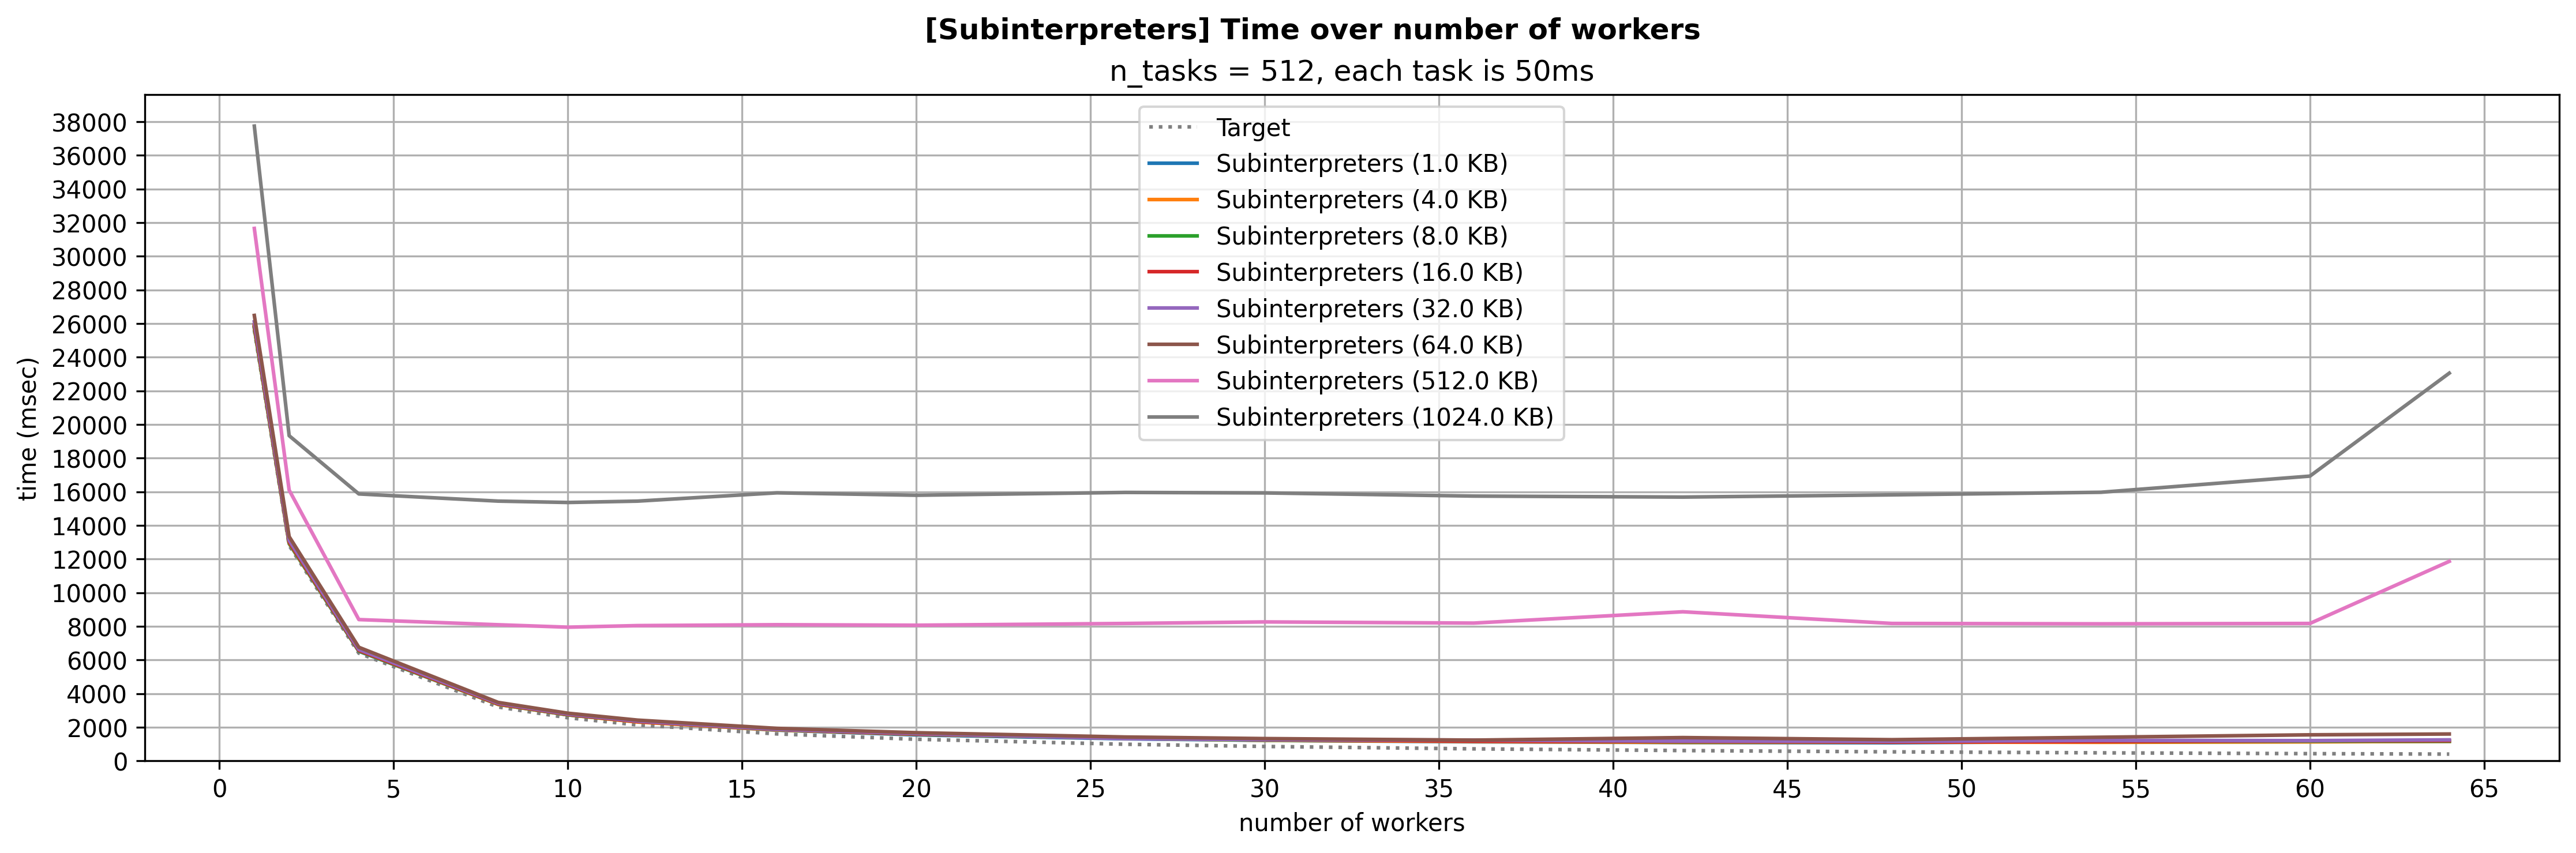

In [21]:
fig, axs = plt.subplots(figsize=(18, 5), dpi=300)
axs.grid()
# Setting the number of ticks
plt.locator_params(axis='x', nbins=len(x_axis_workers)) 
plt.locator_params(axis='y', nbins=24)
plt.plot(x_axis_workers, target, ls="dotted", label="Target", color="grey")
for res in subinterpreters:
    plt.plot(x_axis_workers, res[1], label=f"Subinterpreters ({res[0] / 1024} KB)")

axs.set_xlabel("number of workers")
axs.set_ylabel("time (msec)")
axs.set_ylim(ymin=0)

plt.suptitle('[Subinterpreters] Time over number of workers', y=0.97, fontweight="bold")
plt.title(subtitle)
plt.legend()
#savefig("stream_service_time")
plt.show()

# Comparison

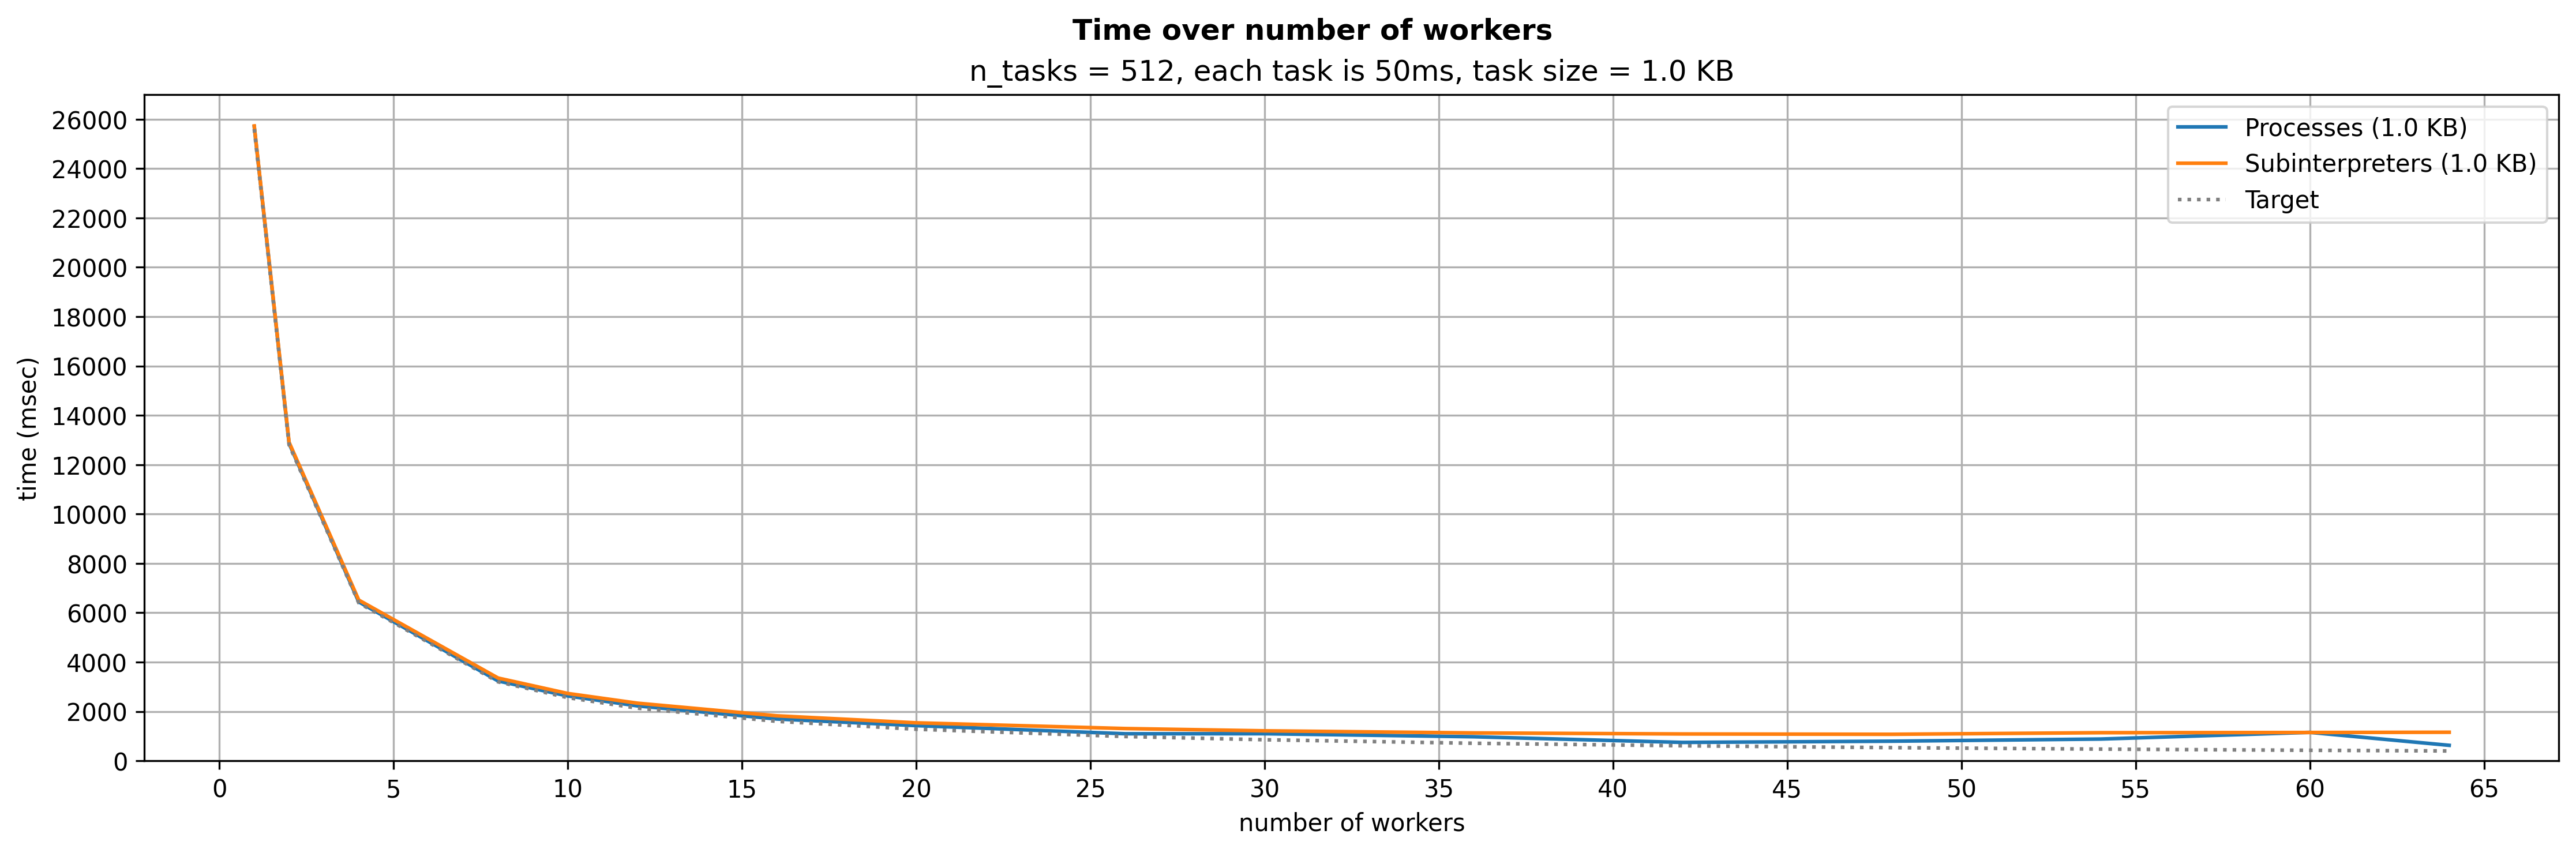

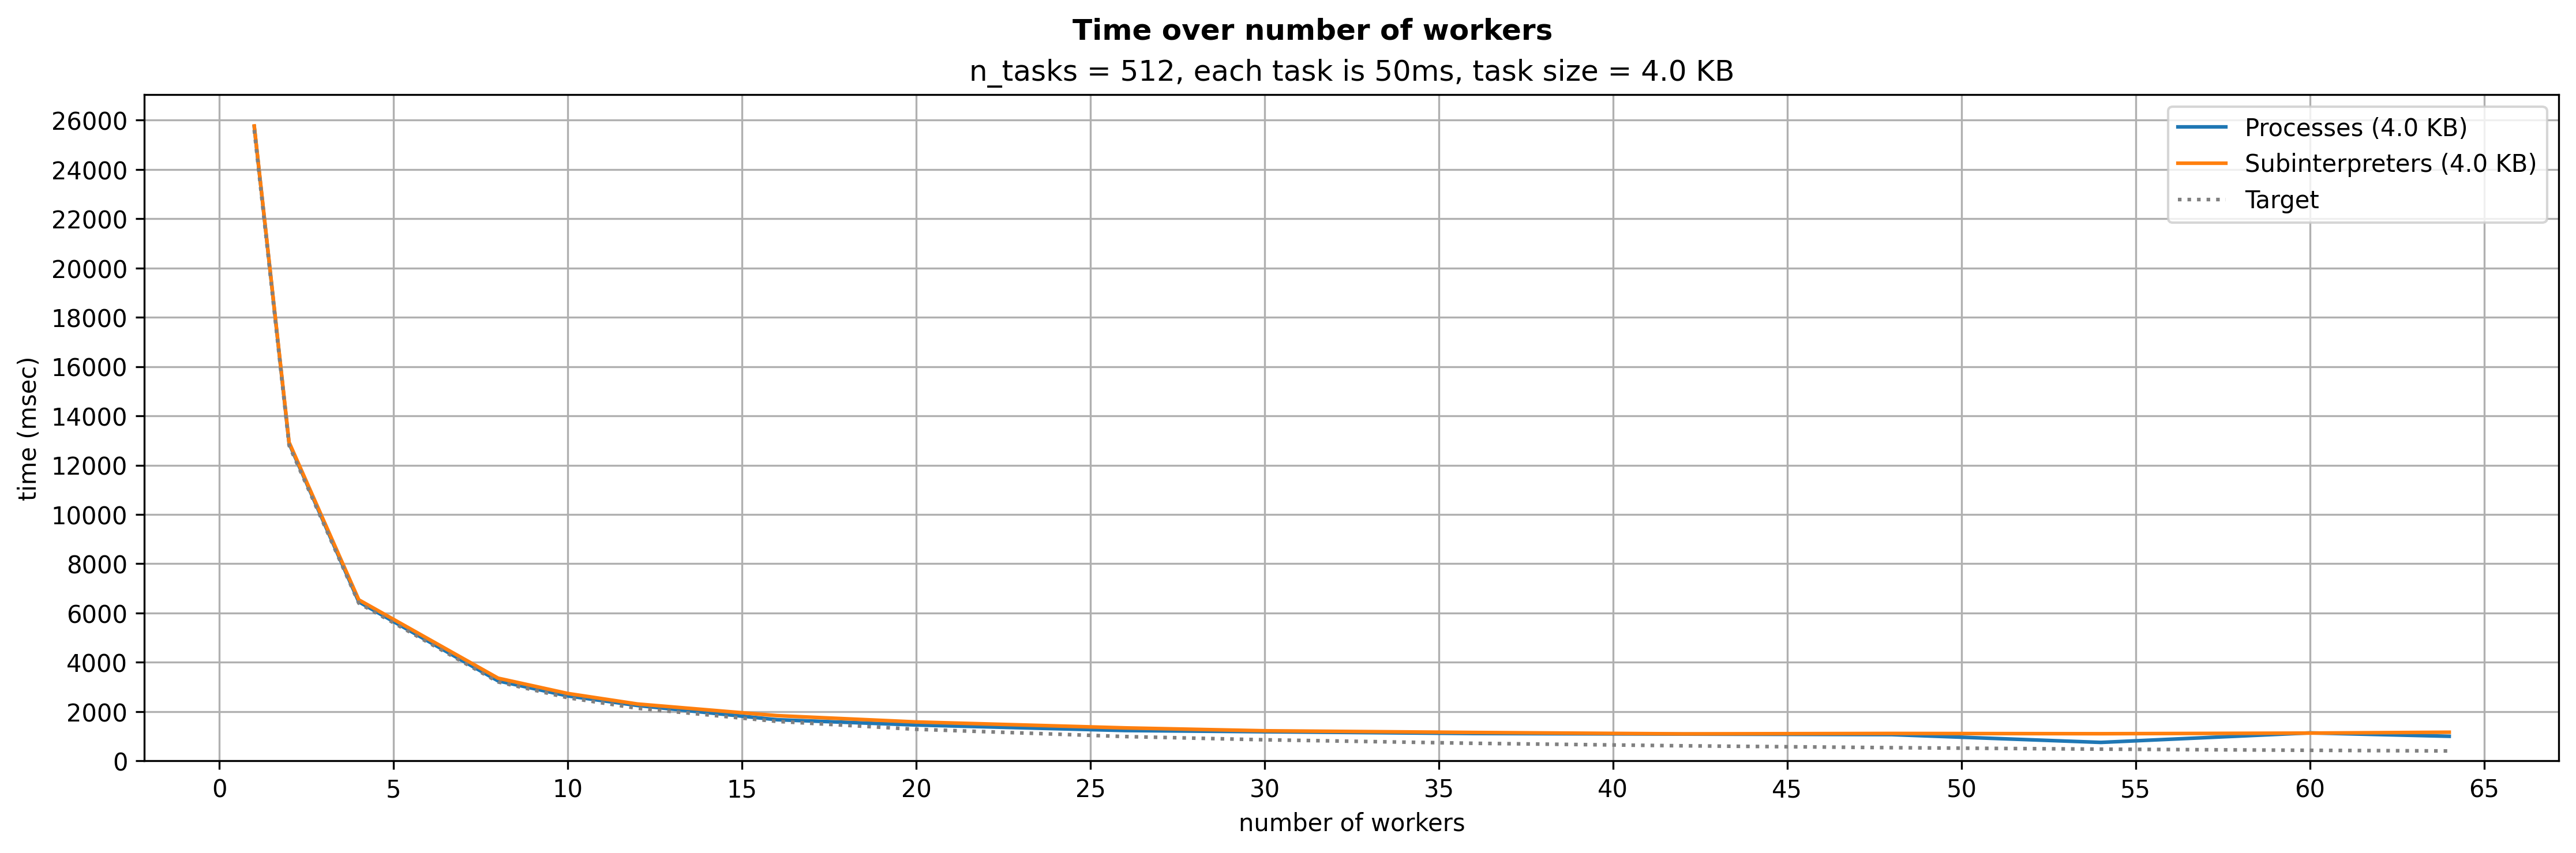

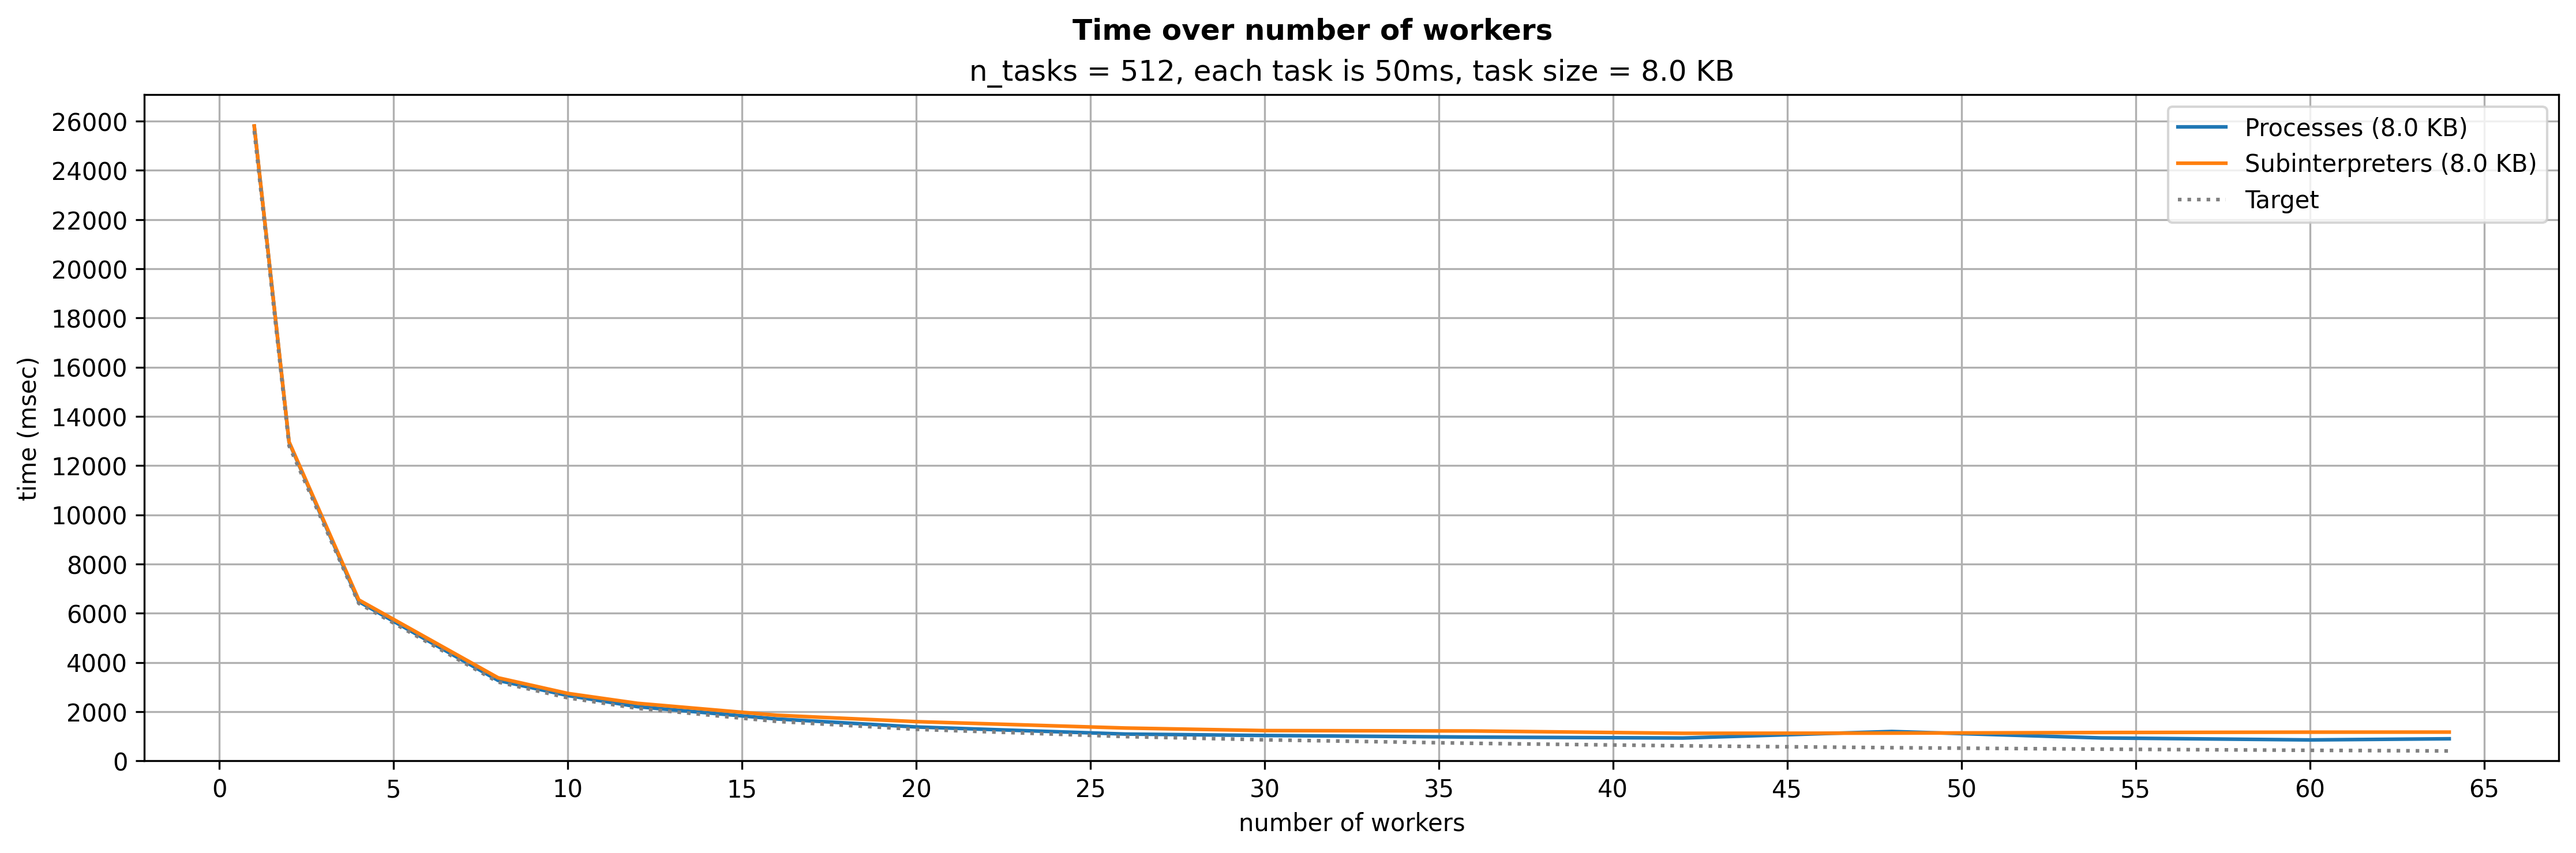

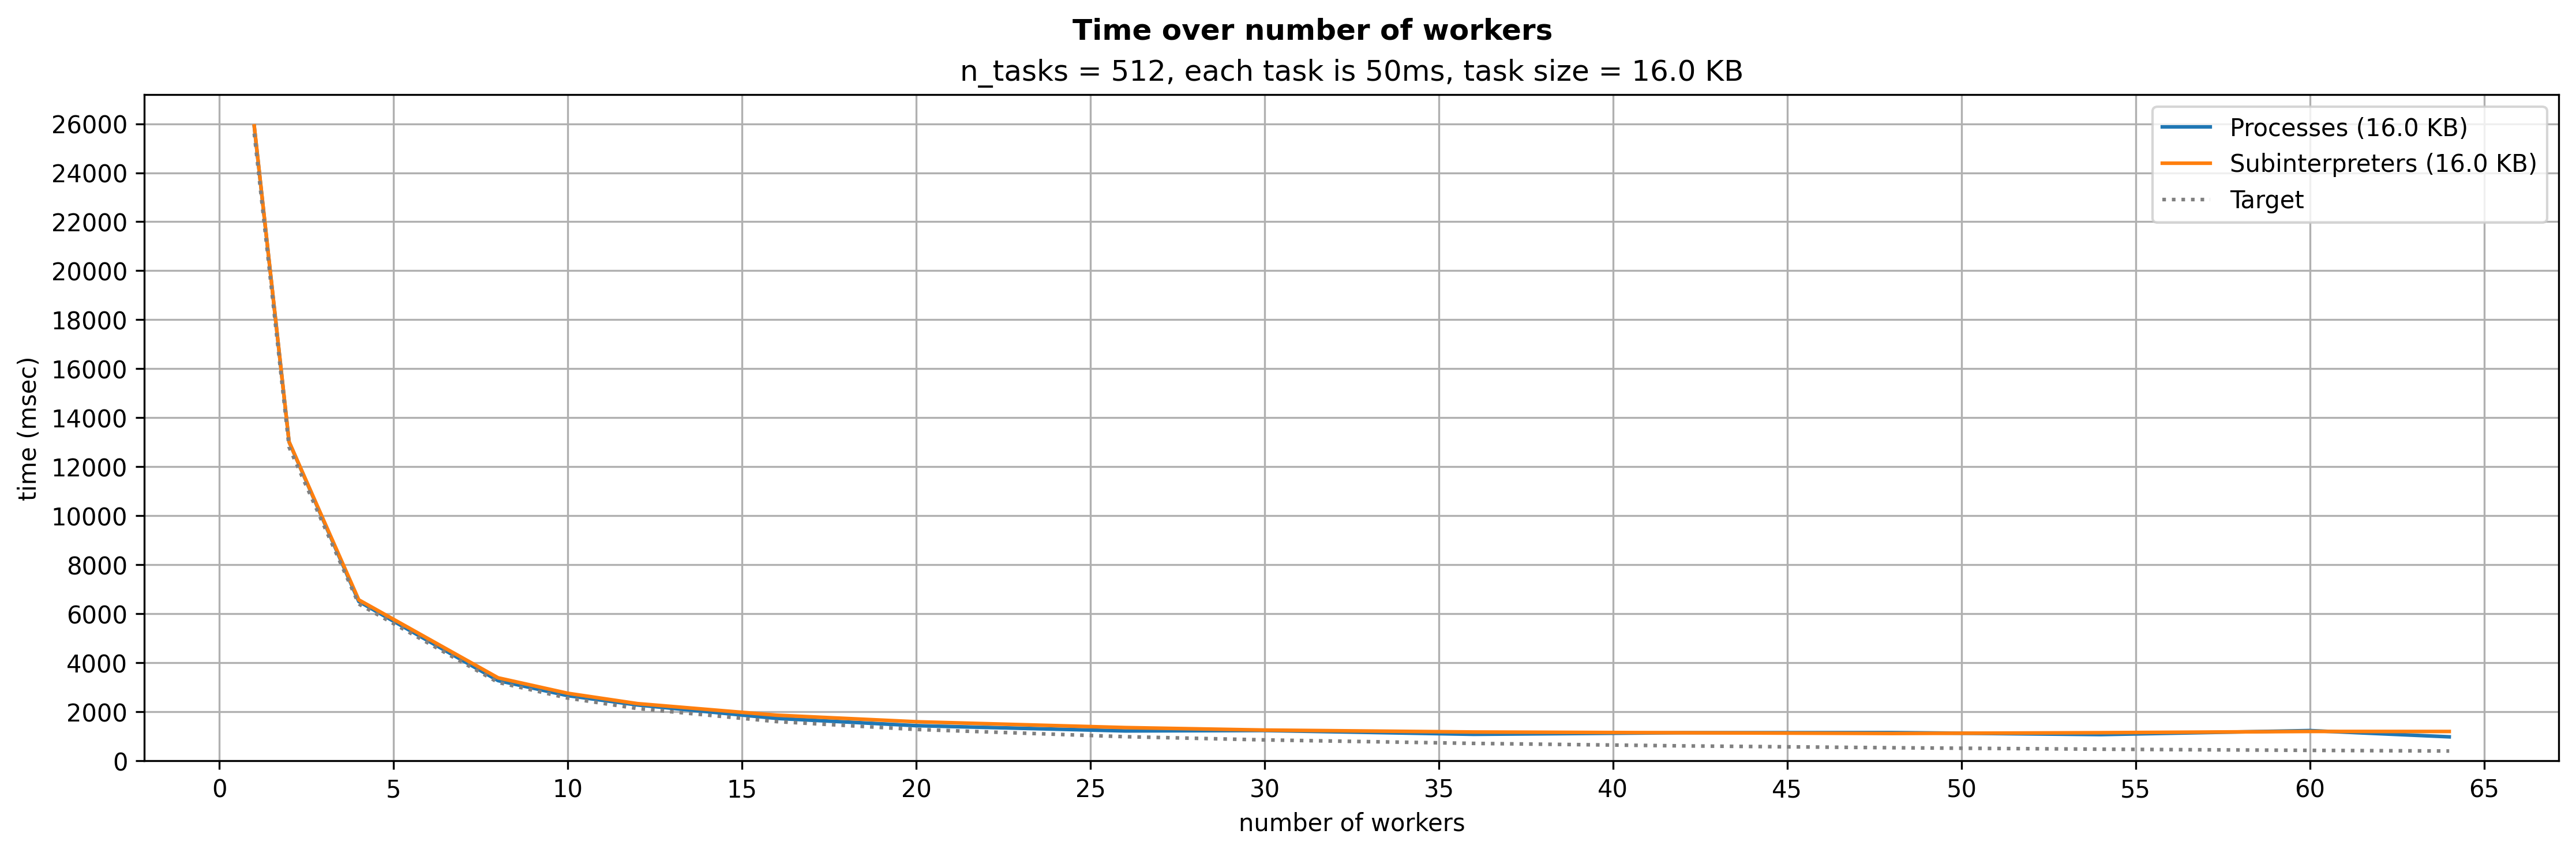

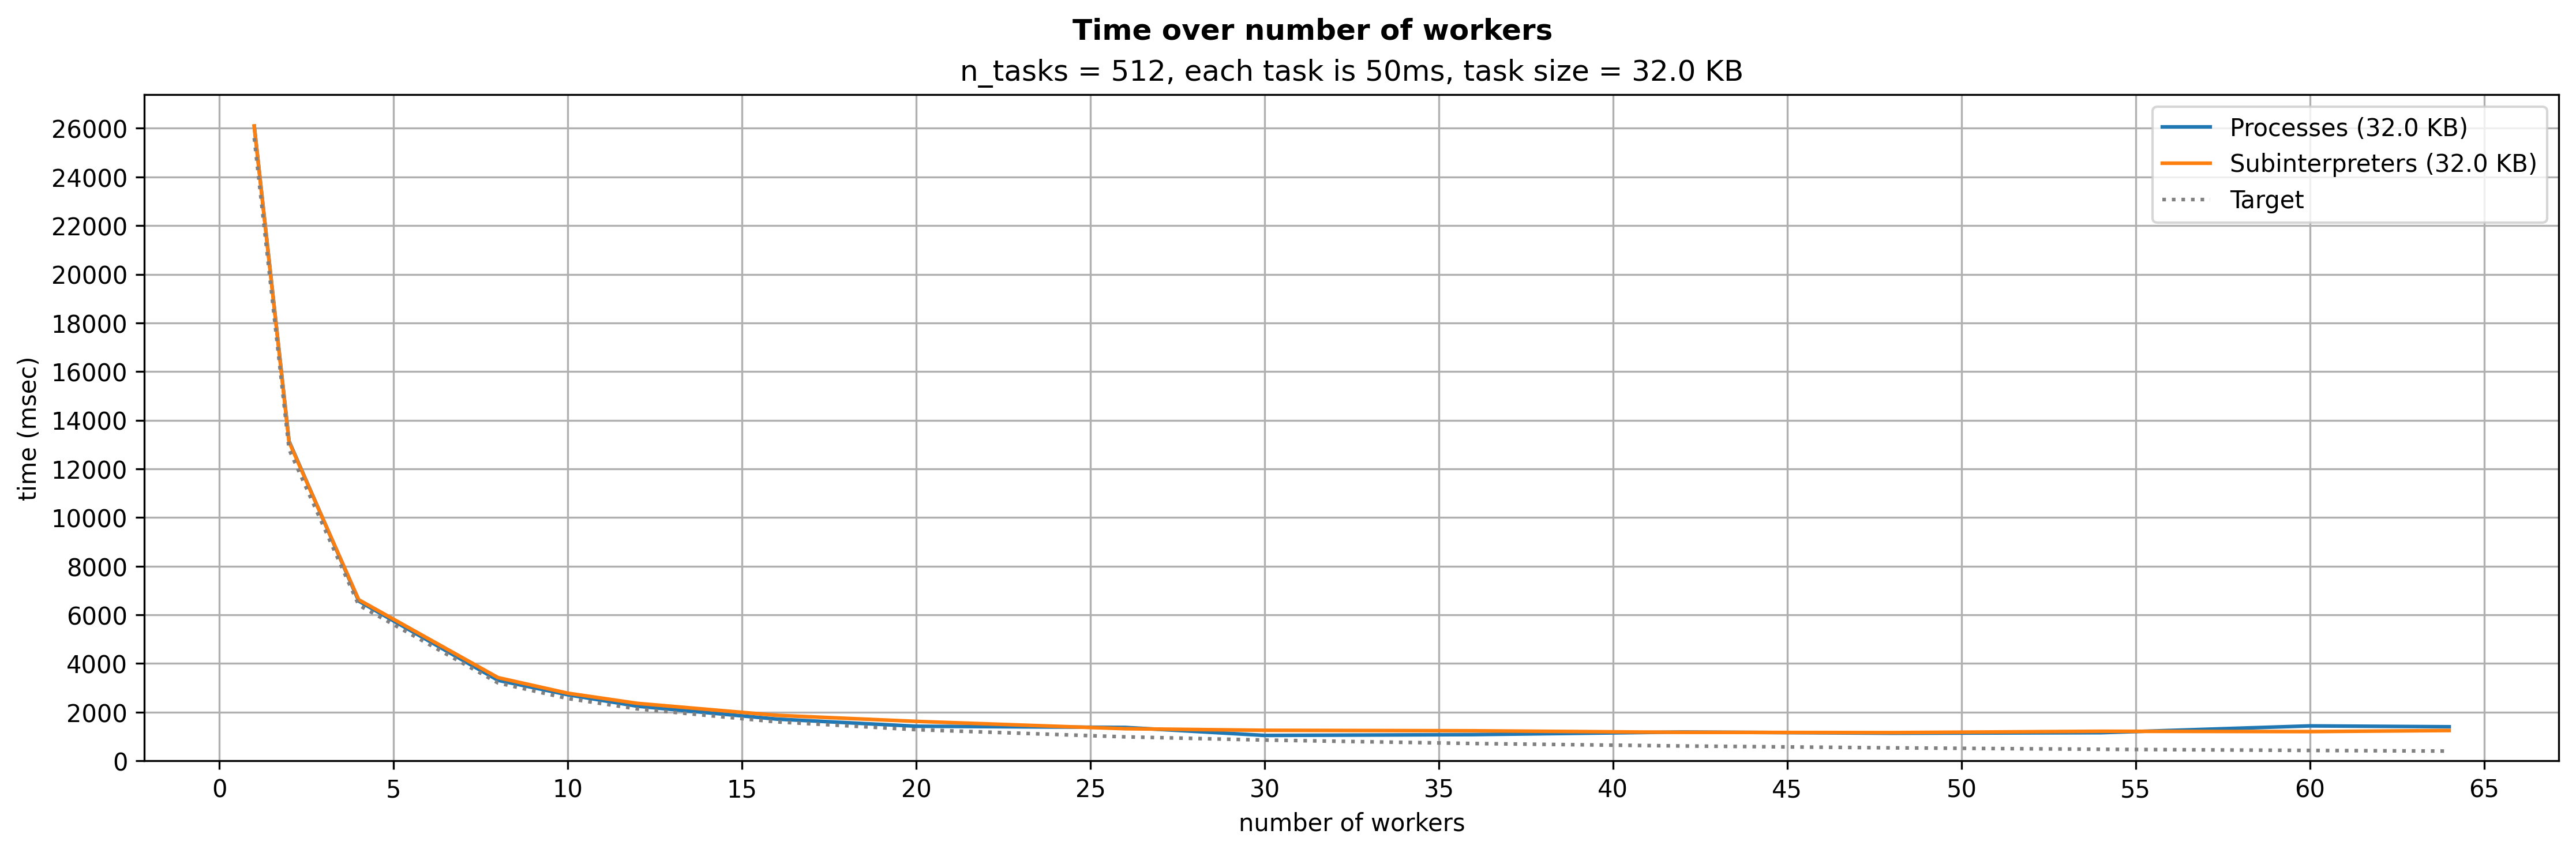

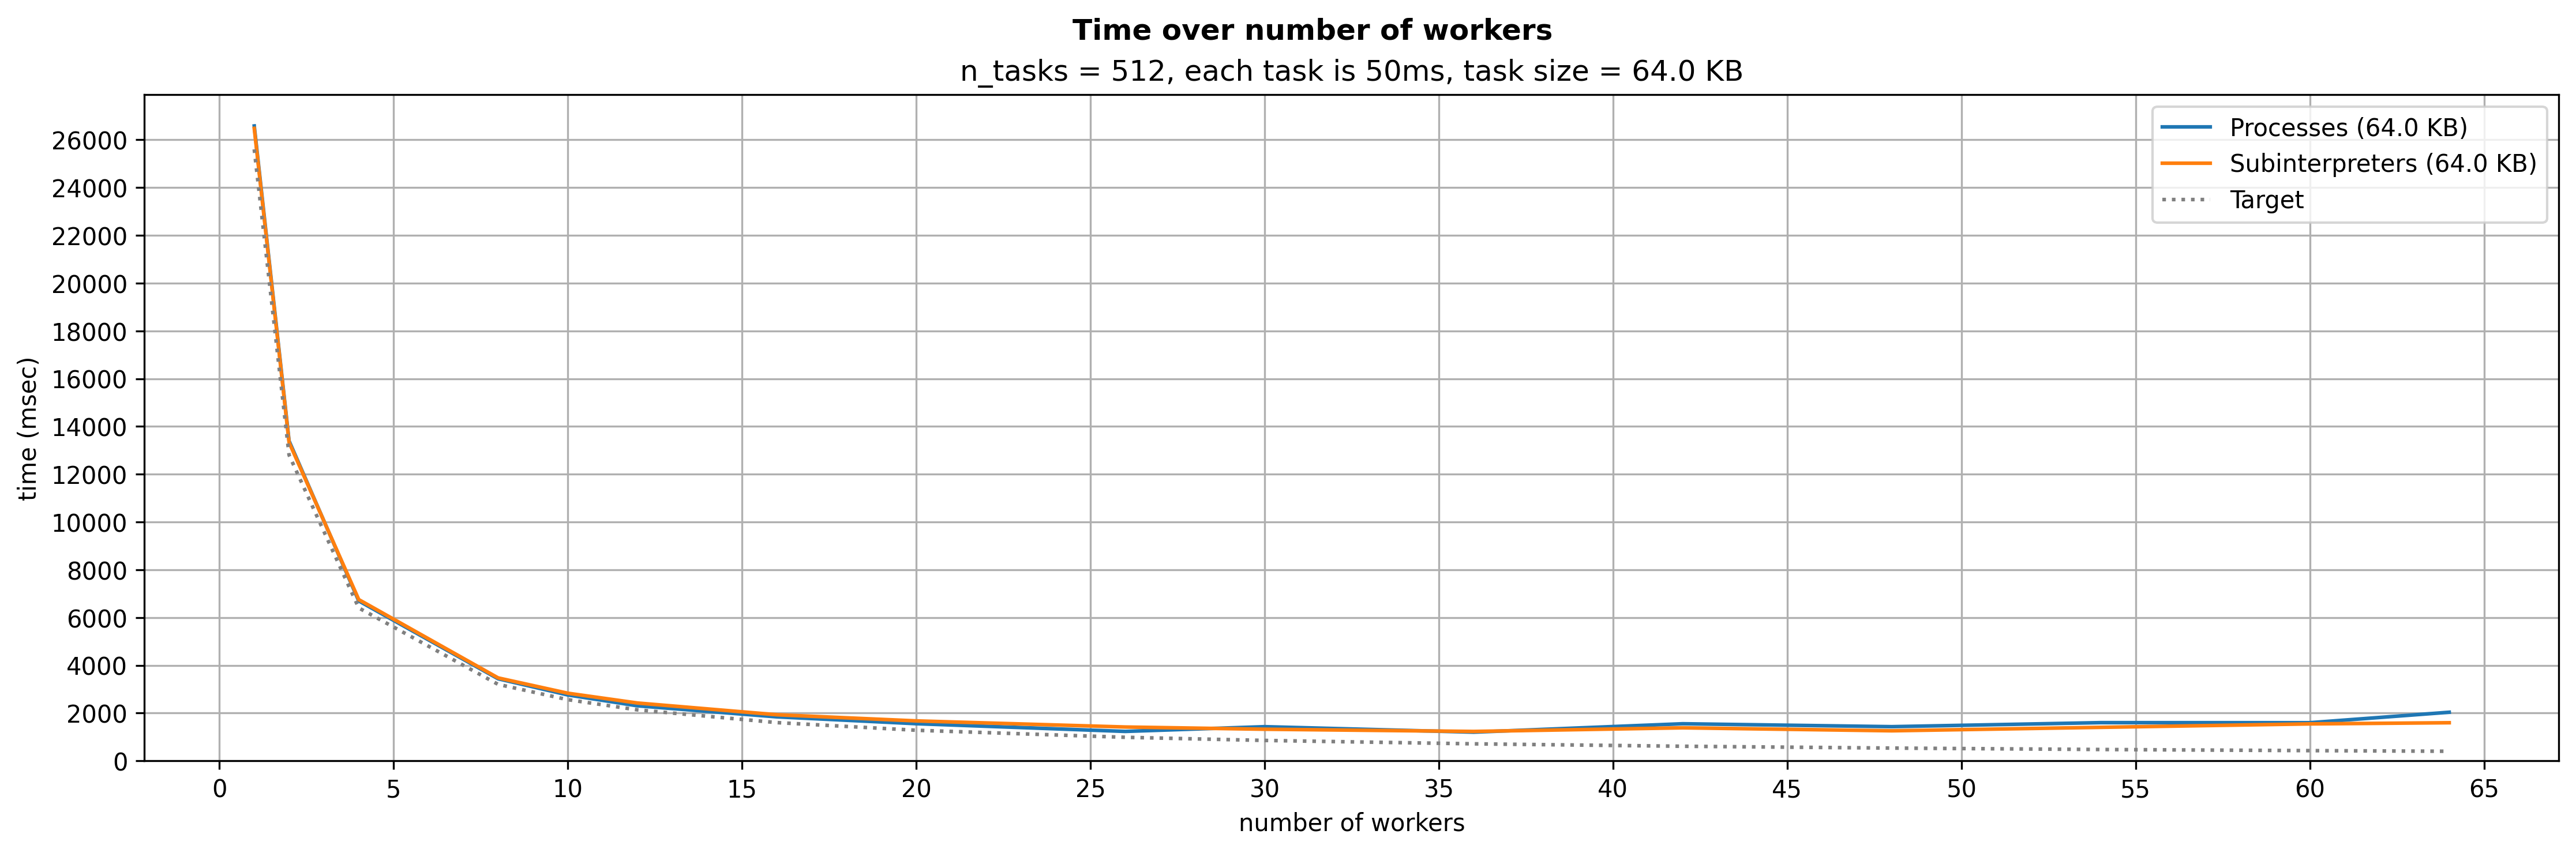

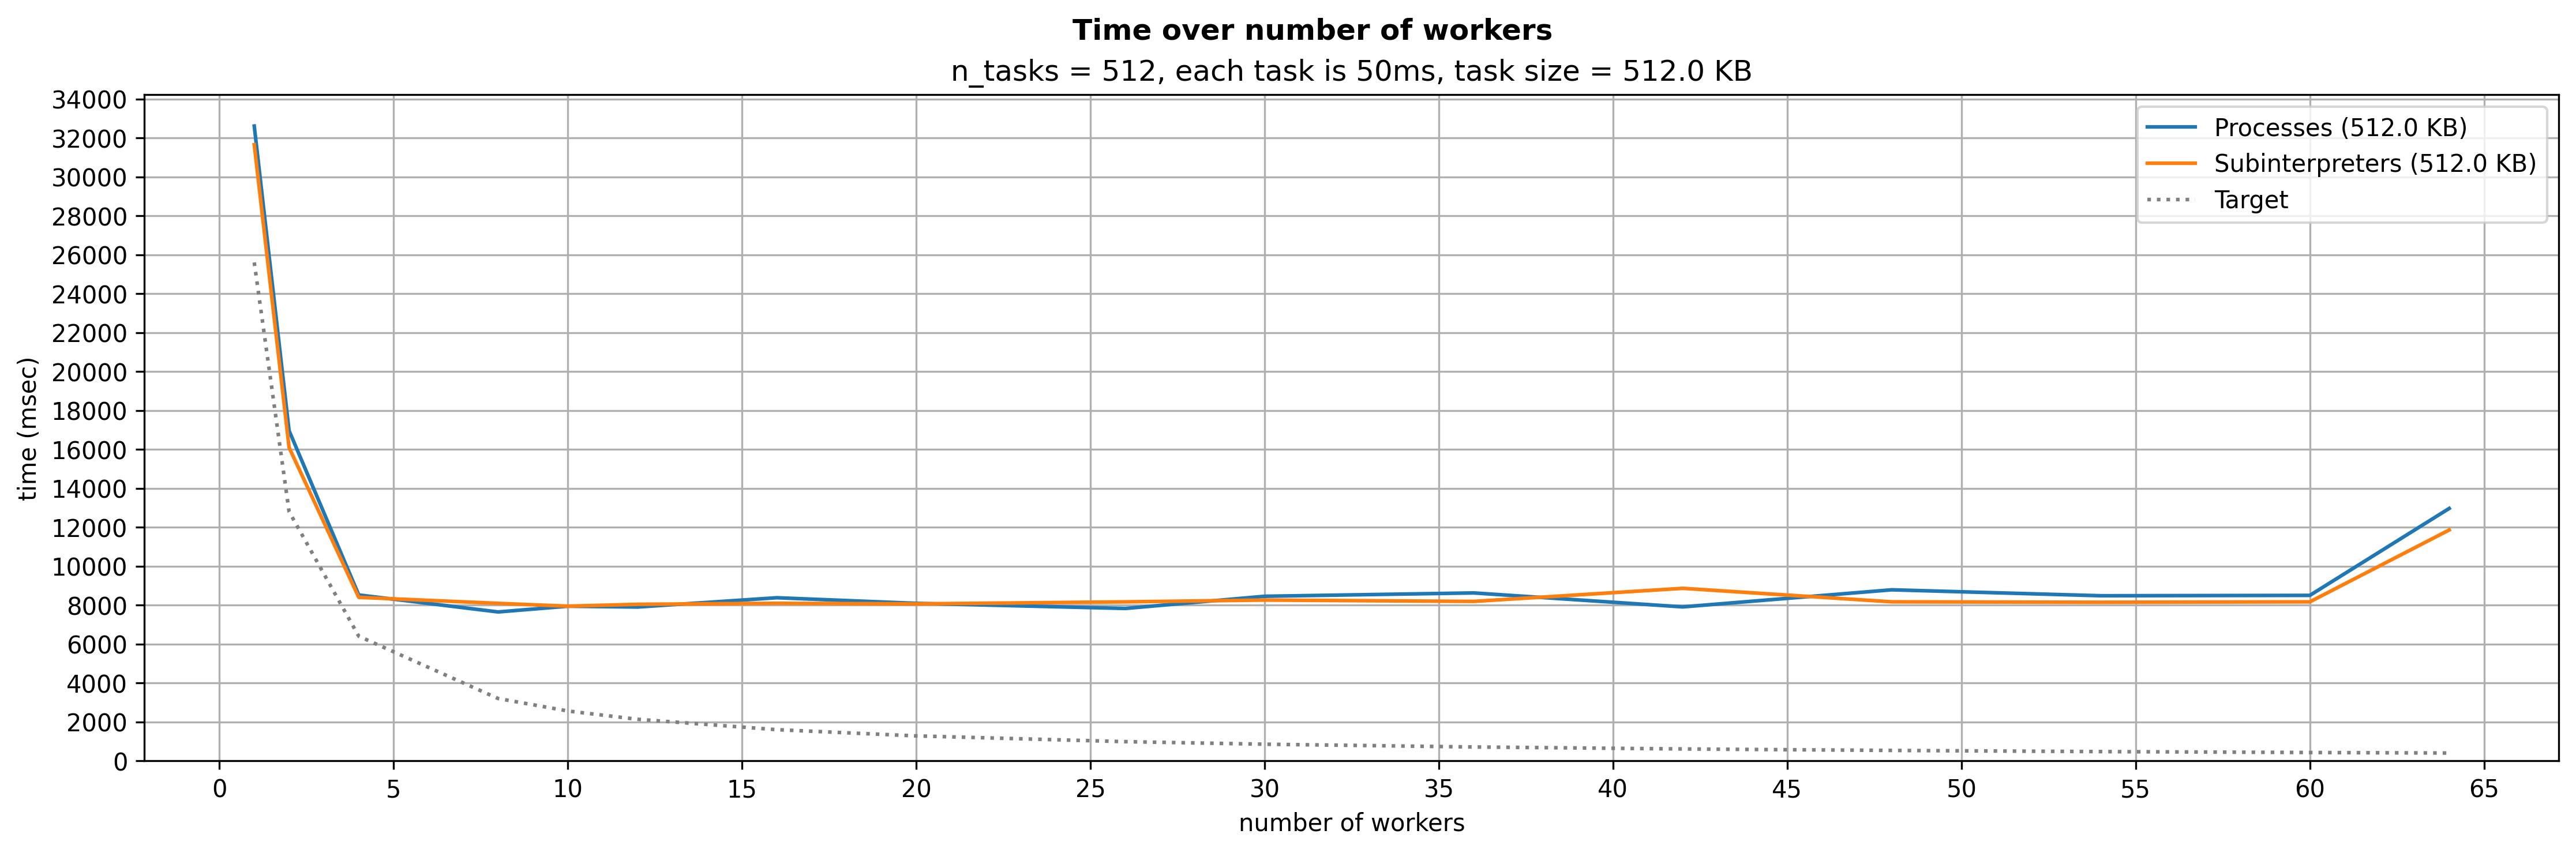

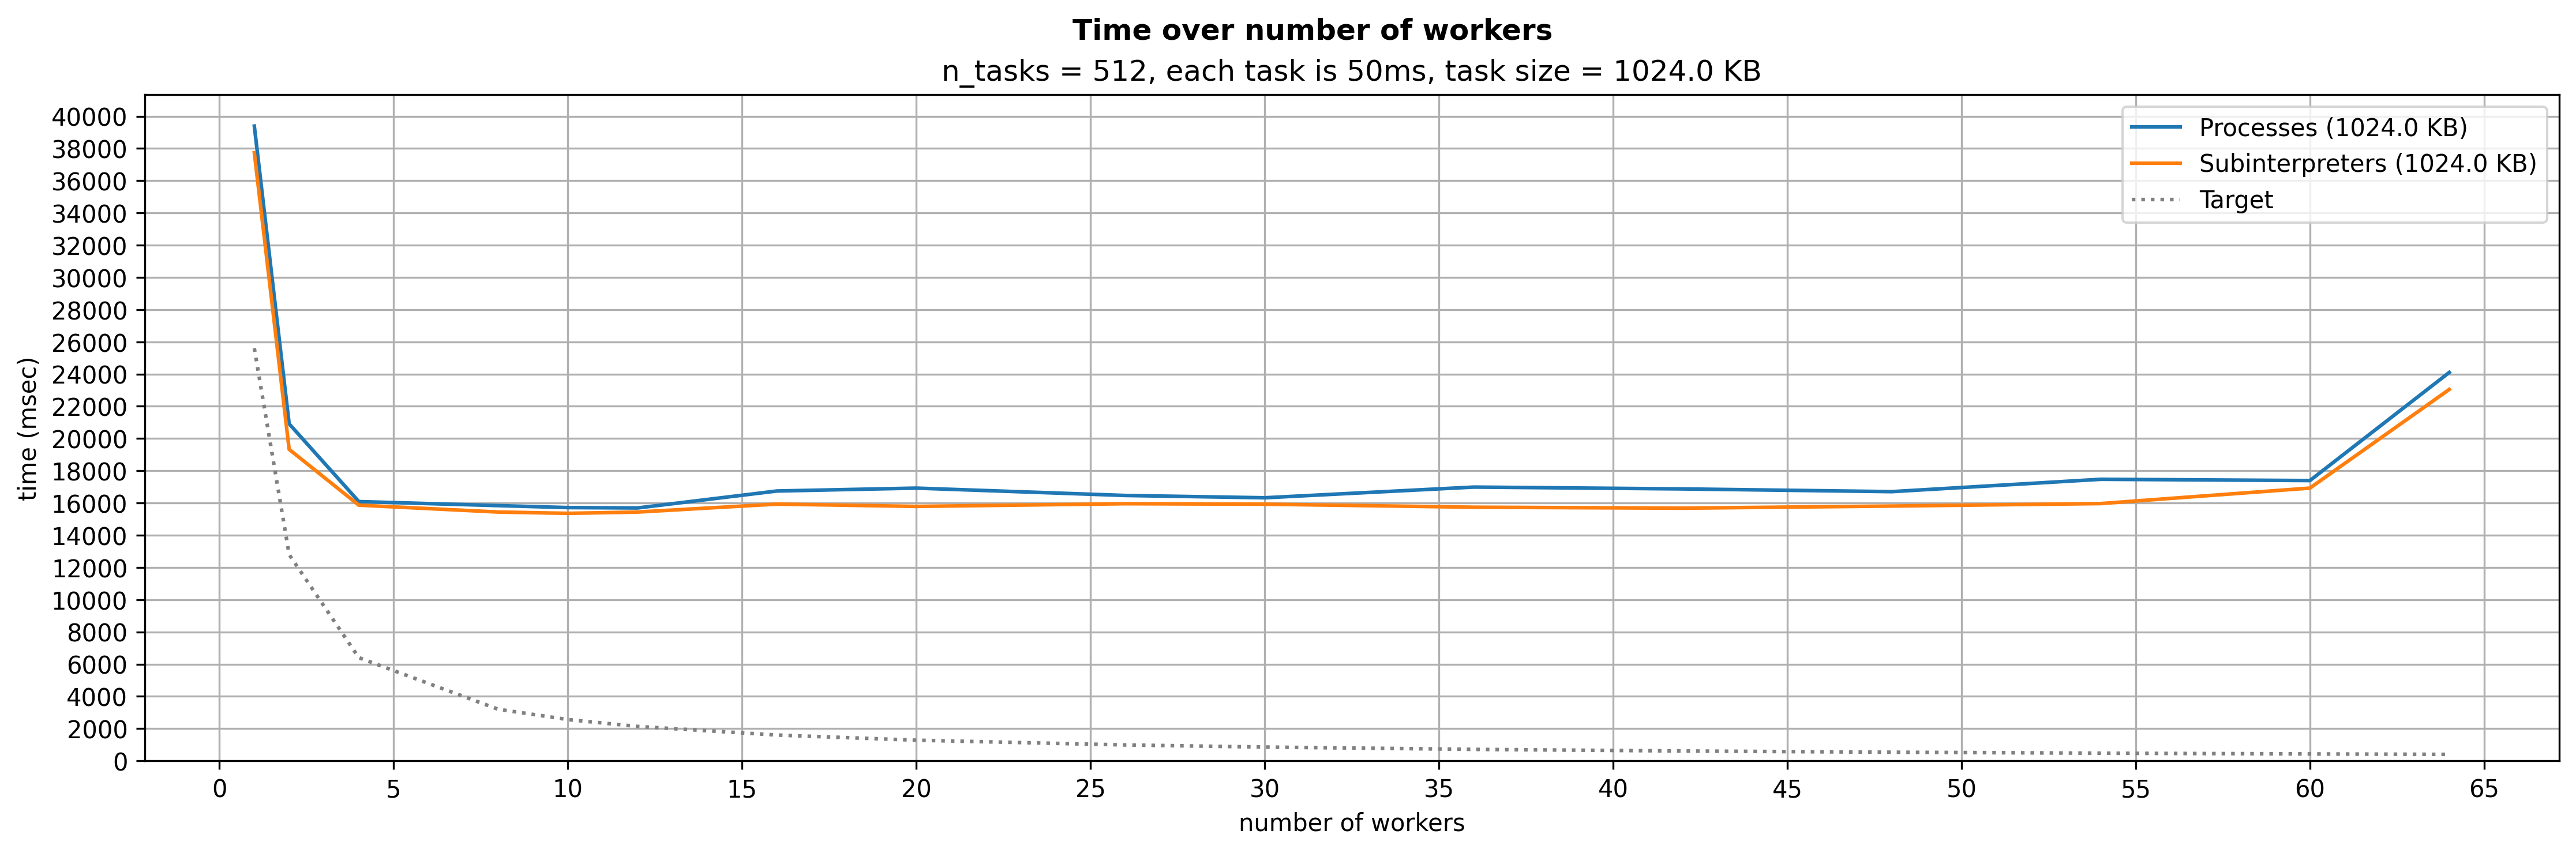

In [22]:
for i in range(len(subinterpreters)):
    fig, axs = plt.subplots(figsize=(18, 5), dpi=300)
    axs.grid()
    # Setting the number of ticks
    plt.locator_params(axis='x', nbins=len(x_axis_workers)) 
    plt.locator_params(axis='y', nbins=24)
    plt.plot(x_axis_workers, processes[i][1], label=f"Processes ({processes[i][0] / 1024} KB)")
    plt.plot(x_axis_workers, subinterpreters[i][1], label=f"Subinterpreters ({subinterpreters[i][0] / 1024} KB)")
    plt.plot(x_axis_workers, target, ls="dotted", label="Target", color="grey")

    axs.set_xlabel("number of workers")
    axs.set_ylabel("time (msec)")
    axs.set_ylim(ymin=0)

    plt.suptitle('Time over number of workers', y=0.97, fontweight="bold")
    plt.title(f"{subtitle}, task size = {processes[i][0] / 1024} KB")
    plt.legend()
    #savefig("stream_service_time")
    plt.show()

In [23]:
"""subinterpreters = []
subinterpreters.append([[1], [25727.92]] )
subinterpreters.append([[1], [25768.715]])
subinterpreters.append([[1], [25806.033]])
subinterpreters.append([[1], [25910.388]])
subinterpreters.append([[1], [26097.686]])
subinterpreters.append([[1], [26477.558]])
subinterpreters.append([[1], [31649.882]]) 
subinterpreters.append([[1], [37733.956]])
subinterpreters.append([[2], [12907.298]])
subinterpreters.append([[2], [12927.752]])
subinterpreters.append([[2], [12961.531]])
subinterpreters.append([[2], [13015.842]] )
subinterpreters.append([[2], [13106.446]] )
subinterpreters.append([[2], [13326.825]] )
subinterpreters.append([[2], [16093.954]] )
subinterpreters.append([[2], [19327.821]] )
subinterpreters.append([[4], [6513.155]] )
subinterpreters.append([[4], [6535.309]] )
subinterpreters.append([[4], [6540.578]] )
subinterpreters.append([[4], [6569.522]] )
subinterpreters.append([[4], [6621.483]] )
subinterpreters.append([[4], [6749.681]])
subinterpreters.append([[4], [8396.406]])
subinterpreters.append([[4], [15865.447]])
subinterpreters.append([[8], [3353.734]])
subinterpreters.append([[8], [3353.889]])
subinterpreters.append([[8], [3374.623]] )
subinterpreters.append([[8], [3386.886]] )
subinterpreters.append([[8], [3419.719]] )
subinterpreters.append([[8], [3471.185]] )
subinterpreters.append([[8], [8089.079]] )
subinterpreters.append([[8], [15438.715]])
subinterpreters.append([[10], [2729.36]] )
subinterpreters.append([[10], [2733.334]])
subinterpreters.append([[10], [2739.531]])
subinterpreters.append([[10], [2756.099]])
subinterpreters.append([[10], [2780.366]])
subinterpreters.append([[10], [2830.488]] )
subinterpreters.append([[10], [7944.209]] )
subinterpreters.append([[10], [15357.766]])
subinterpreters.append([[12], [2335.822]] )
subinterpreters.append([[12], [2306.13]] )
subinterpreters.append([[12], [2337.694]] )
subinterpreters.append([[12], [2334.773]] )
subinterpreters.append([[12], [2361.988]] )
subinterpreters.append([[12], [2420.055]] )
subinterpreters.append([[12], [8039.08]] )
subinterpreters.append([[12], [15437.643]])
subinterpreters.append([[16], [1823.786]] )
subinterpreters.append([[16], [1833.637]] )
subinterpreters.append([[16], [1851.678]] )
subinterpreters.append([[16], [1861.322]] )
subinterpreters.append([[16], [1869.841]] )
subinterpreters.append([[16], [1929.0]] )
subinterpreters.append([[16], [8091.909]] )
subinterpreters.append([[16], [15931.93]] )
subinterpreters.append([[20], [1540.081]] )
subinterpreters.append([[20], [1577.891]] )
subinterpreters.append([[20], [1592.95]] )
subinterpreters.append([[20], [1595.262]] )
subinterpreters.append([[20], [1621.942]] )
subinterpreters.append([[20], [1671.784]] )
subinterpreters.append([[20], [8061.244]] ) 
subinterpreters.append([[20], [15787.879]])
subinterpreters.append([[26], [1308.053]] )
subinterpreters.append([[26], [1336.833]] )
subinterpreters.append([[26], [1333.041]] )
subinterpreters.append([[26], [1356.953]] ) 
subinterpreters.append([[26], [1319.765]] ) 
subinterpreters.append([[26], [1415.432]] ) 
subinterpreters.append([[26], [8165.698]] )
subinterpreters.append([[26], [15955.424]])
subinterpreters.append([[30], [1215.727]] )
subinterpreters.append([[30], [1219.759]] )
subinterpreters.append([[30], [1229.074]] )
subinterpreters.append([[30], [1255.368]] ) 
subinterpreters.append([[30], [1254.545]] )
subinterpreters.append([[30], [1322.231]] )
subinterpreters.append([[30], [8257.655]] )
subinterpreters.append([[30], [15926.648]])
subinterpreters.append([[36], [1130.424]] )
subinterpreters.append([[36], [1151.612]] )
subinterpreters.append([[36], [1212.993]] )
subinterpreters.append([[36], [1175.823]] )
subinterpreters.append([[36], [1235.056]] )
subinterpreters.append([[36], [1230.076]] )
subinterpreters.append([[36], [8188.382]] )
subinterpreters.append([[36], [15737.713]])
subinterpreters.append([[42], [1088.292]] )
subinterpreters.append([[42], [1094.12]] )
subinterpreters.append([[42], [1119.029]] )
subinterpreters.append([[42], [1145.7]] )
subinterpreters.append([[42], [1170.622]] )
subinterpreters.append([[42], [1381.259]] )
subinterpreters.append([[42], [8860.677]] )
subinterpreters.append([[42], [15678.617]])
subinterpreters.append([[48], [1075.262]] )
subinterpreters.append([[48], [1110.996]] )
subinterpreters.append([[48], [1125.75]] )
subinterpreters.append([[48], [1115.225]] )
subinterpreters.append([[48], [1160.126]] )
subinterpreters.append([[48], [1256.786]] )
subinterpreters.append([[48], [8166.868]] )
subinterpreters.append([[48], [15810.114]])
subinterpreters.append([[54], [1139.679]] )
subinterpreters.append([[54], [1099.914]] )
subinterpreters.append([[54], [1150.677]] )
subinterpreters.append([[54], [1148.109]] )
subinterpreters.append([[54], [1214.386]] )
subinterpreters.append([[54], [1401.778]] )
subinterpreters.append([[54], [8143.988]] )
subinterpreters.append([[54], [15964.421]])
subinterpreters.append([[60], [1148.209]] )
subinterpreters.append([[60], [1125.462]] )
subinterpreters.append([[60], [1164.54]] )
subinterpreters.append([[60], [1198.941]] )
subinterpreters.append([[60], [1201.17]] )
subinterpreters.append([[60], [1545.387]] )
subinterpreters.append([[60], [8165.96]] )
subinterpreters.append([[60], [16924.99]] )
subinterpreters.append([[64], [1158.0]] )
subinterpreters.append([[64], [1160.896]] )
subinterpreters.append([[64], [1167.316]] )
subinterpreters.append([[64], [1197.512]] )
subinterpreters.append([[64], [1245.139]] )
subinterpreters.append([[64], [1594.439]] )
subinterpreters.append([[64], [11857.307]] )
subinterpreters.append([[64], [23046.367]] )

data = subinterpreters
mp = {}
for proc in data:
    mp[proc[0][0]] = []
for proc in data:
    mp[proc[0][0]].append(proc[1][0])
print(mp)
final = []
for i in range(len(mp[proc[0][0]])):
    row = []
    final.append(row)
    for nw, res in mp.items():
        row.append(res[i])
print(final)
"""


'subinterpreters = []\nsubinterpreters.append([[1], [25727.92]] )\nsubinterpreters.append([[1], [25768.715]])\nsubinterpreters.append([[1], [25806.033]])\nsubinterpreters.append([[1], [25910.388]])\nsubinterpreters.append([[1], [26097.686]])\nsubinterpreters.append([[1], [26477.558]])\nsubinterpreters.append([[1], [31649.882]]) \nsubinterpreters.append([[1], [37733.956]])\nsubinterpreters.append([[2], [12907.298]])\nsubinterpreters.append([[2], [12927.752]])\nsubinterpreters.append([[2], [12961.531]])\nsubinterpreters.append([[2], [13015.842]] )\nsubinterpreters.append([[2], [13106.446]] )\nsubinterpreters.append([[2], [13326.825]] )\nsubinterpreters.append([[2], [16093.954]] )\nsubinterpreters.append([[2], [19327.821]] )\nsubinterpreters.append([[4], [6513.155]] )\nsubinterpreters.append([[4], [6535.309]] )\nsubinterpreters.append([[4], [6540.578]] )\nsubinterpreters.append([[4], [6569.522]] )\nsubinterpreters.append([[4], [6621.483]] )\nsubinterpreters.append([[4], [6749.681]])\nsubi